In [1]:
!pip install pandas numpy torch biopython scikit-learn streamlit gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 46.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 44.0 MB/s eta 0:00:00


In [2]:
from google.colab import drive
import os

# 1. 구글 드라이브 마운트
drive.mount('/content/drive')

# 2. 작업 경로 설정 (파일 위치에 맞게 수정)
# 예: 'My Drive' 하위의 'Peptide_Project' 폴더
WORKING_DIR = "/content/drive/MyDrive/Peptide_Project"
if not os.path.exists(WORKING_DIR):
    os.makedirs(WORKING_DIR)
    print(f"📁 폴더를 생성했습니다: {WORKING_DIR}")

# 3. 데이터 파일 경로 정의
print(f"📍 현재 작업 경로: {WORKING_DIR}")

Mounted at /content/drive
📍 현재 작업 경로: /content/drive/MyDrive/Peptide_Project


In [3]:
!pip install sympy==1.12.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 17.5 MB/s eta 0:00:00
  Attempting uninstall: sympy
    Found existing installation: sympy 1.14.0
    Uninstalling sympy-1.14.0:
      Successfully uninstalled sympy-1.14.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.10.0+cu128 requires sympy>=1.13.3, but you have sympy 1.12.1 which is incompatible.


In [4]:
# ==========================================
# ⚙️ [SYSTEM CONFIG] 통합 제어 패널
# ==========================================
system_config = {
    "data_params": {
        "dataset_path": "/content/drive/MyDrive/Peptide_Project/tcell_table_export_1775912610.csv",
        "quick_test_mode": False,      # PoC를 위한 5000개 샘플링 여부
        "apply_augmentation": False    # 데이터 불균형 시 생물학적 돌연변이 증강 적용
    },
    "design_constraints": {
        "base_sequence": "AUTO",      # AUTO 설정 시 hCD47 핵심 서열 사용
        "hCD47_reference": "EVTELT",  # 대식세포 억제 신호(Don't eat me) 모티프
        "max_peptide_length": 15      # 펩타이드 최대 길이 (IEDB T-cell 데이터 최적화)
    },
    "algorithm_params": {
        "ga_population_size": 50,
        "ga_generations": 30,
        "ga_mutation_rate": 0.05,
        "top_n_candidates": 5         # 최종 도출할 고유(Unique) 서열 개수
    },
    "weights": {
        "w_1_ai": 0.5,        # P_FBR (염증 예측) 비중
        "w_2_gravy": 0.15,    # 소수성(물리화학적 안정성) 비중
        "w_3_charge": 0.15,   # 전하(생체 내 거동) 비중
        "w_4_cd47": 0.2       # H_CD47 (기능적 상동성 유지) 비중
    },
    "training_params": {
        "epochs": 100,                  # 실전 모드를 위한 충분한 학습 횟수
        "save_path": "best_peptide_model.pth" # 최적 가중치 저장 파일명
    }
}

In [9]:
import random
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from Bio.Align import substitution_matrices
from Bio import Align
from Bio.SeqUtils.ProtParam import ProteinAnalysis
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import time
import tracemalloc

# ==========================================
# 1. 데이터 파이프라인 (Bio-Domain Logic)
# ==========================================
def build_blosum62_embedding():
    """
    BLOSUM62 행렬을 이용한 임베딩 레이어 생성.
    아미노산 간의 진화적/생물학적 치환 가능성을 가중치에 반영하여
    AI가 서열의 단순 배열이 아닌 '생물학적 의미'를 학습하게 함.
    """
    blosum62 = substitution_matrices.load("BLOSUM62")
    alphabet = blosum62.alphabet
    aa_to_idx = {'PAD': 0}
    for i, aa in enumerate(alphabet): aa_to_idx[aa] = i + 1

    weight_matrix = torch.zeros((len(aa_to_idx), len(alphabet)))
    for aa1, idx in aa_to_idx.items():
        if aa1 == 'PAD': continue
        for j, aa2 in enumerate(alphabet): weight_matrix[idx, j] = blosum62[aa1, aa2]

    # Min-Max Scaling: 가중치 범위를 [0, 1]로 정규화하여 학습 안정성 확보
    min_val, max_val = weight_matrix.min(), weight_matrix.max()
    weight_matrix = (weight_matrix - min_val) / (max_val - min_val)
    return nn.Embedding.from_pretrained(weight_matrix, freeze=False, padding_idx=0), aa_to_idx, len(alphabet)

class IEDBPeptideDataset(Dataset):
    """IEDB 데이터를 펩타이드 분석에 적합하도록 정제 및 증강하는 클래스 (GPU 최적화 적용)"""
    def __init__(self, config, aa_to_idx):
        self.max_len = config["design_constraints"]["max_peptide_length"]
        self.aa_to_idx = aa_to_idx

        # 1. 초기 더미 데이터 셋팅
        self.data = pd.DataFrame({'Sequence': ['EVTELT', 'ARNDCQ']*10, 'Target': [0, 1]*10})

        # 2. 실제 데이터 로드 시도
        try:
            raw_data = pd.read_csv(config["data_params"]["dataset_path"], low_memory=False)
            seq_col, target_col = 'Epitope - Name', 'Assay - Qualitative Measurement'
            if seq_col in raw_data.columns and target_col in raw_data.columns:
                temp = raw_data[[seq_col, target_col]].copy()
                temp.columns = ['Sequence', 'Target']
                temp['Target'] = temp['Target'].apply(lambda x: 1 if isinstance(x, str) and 'Positive' in x else 0)
                temp = temp.dropna().loc[temp['Sequence'].str.len() <= self.max_len]
                if len(temp) > 0: self.data = temp
        except:
            print("⚠️ CSV 로드 실패. 더미 데이터로 진행합니다.")

        # 3. 데이터 증강 (Augmentation)
        if config["data_params"]["apply_augmentation"]:
            pos_data = self.data[self.data['Target'] == 1]
            neg_data = self.data[self.data['Target'] == 0]
            if abs(len(pos_data) - len(neg_data)) > len(self.data) * 0.1:
                minority = pos_data if len(pos_data) < len(neg_data) else neg_data
                diff = abs(len(pos_data) - len(neg_data))
                aug_seqs = ["".join(random.choice("ACDEFGHIKLMNPQRSTVWY") if random.random() < 0.1 else aa for aa in s)
                            for s in minority['Sequence'].sample(diff, replace=True)]
                aug_df = pd.DataFrame({'Sequence': aug_seqs, 'Target': [minority['Target'].iloc[0]]*diff})
                self.data = pd.concat([self.data, aug_df], ignore_index=True)

        # 💡 [GPU 최적화] __getitem__ 에서의 실시간 연산을 없애기 위한 텐서 사전 변환 (Pre-computation)
        print("⏳ 데이터를 GPU 학습에 최적화된 텐서 포맷으로 사전 변환 중입니다...")
        sequences_raw = self.data['Sequence'].tolist()
        labels_raw = self.data['Target'].tolist()

        self.tensor_sequences = []
        self.tensor_labels = []

        for seq, label in zip(sequences_raw, labels_raw):
            # 매번 계산하던 패딩을 처음 초기화할 때 딱 한 번만 수행
            pad = ['PAD'] * (self.max_len - len(seq)) + list(seq)
            idx_seq = [self.aa_to_idx.get(aa, 0) for aa in pad]

            self.tensor_sequences.append(torch.tensor(idx_seq, dtype=torch.long))
            self.tensor_labels.append(torch.tensor([label], dtype=torch.float32))

    def __len__(self):
        return len(self.tensor_sequences)

    def __getitem__(self, idx):
        # 💡 이미 변환된 텐서를 꺼내주기만 하면 되므로 CPU 오버헤드가 0에 수렴함
        if torch.is_tensor(idx):
            idx = idx.tolist()

        return self.tensor_sequences[idx], self.tensor_labels[idx]

# ==========================================
# 2. Pipeline A: 과적합 방지 아키텍처 및 학습 로직
# ==========================================
class FBPredictor(nn.Module):
    def __init__(self, embedding_layer, embed_dim):
        super(FBPredictor, self).__init__()
        self.embedding = embedding_layer
        self.conv = nn.Conv1d(embed_dim, 32, kernel_size=3, padding=1)
        # 💡 [처방 3] 합성곱 이후에도 가벼운 Dropout(0.2) 추가
        self.dropout_cnn = nn.Dropout(0.2)

        self.lstm = nn.LSTM(32, 64, num_layers=2, batch_first=True, bidirectional=True, dropout=0.3)

        self.fc = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            # 💡 [처방 3] 완전연결층의 Dropout을 0.4에서 0.5(50%)로 강력하게 상향
            nn.Dropout(0.3),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.embedding(x).permute(0, 2, 1)
        x = self.dropout_cnn(F.relu(self.conv(x))).permute(0, 2, 1)
        _, (h_n, _) = self.lstm(x)
        return self.fc(torch.cat((h_n[-2,:,:], h_n[-1,:,:]), dim=1))

In [10]:
import torch

print("⚙️ [시스템 준비] 데이터셋 및 임베딩 레이어 초기화 중...")

# 1. device 선언 (GPU/CPU 가속 설정)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. embed_layer, embed_dim 선언 (BLOSUM62 진화적 임베딩)
embed_layer, aa_idx, embed_dim = build_blosum62_embedding()

# 3. dataset 선언 (IEDB 펩타이드 데이터 로드 및 텐서 변환)
dataset = IEDBPeptideDataset(system_config, aa_idx)

# (선택) 퀵 테스트 모드 설정 (빠른 실험을 위해 5000개만 샘플링)
if system_config["data_params"]["quick_test_mode"] and len(dataset) > 5000:
    dataset = torch.utils.data.Subset(dataset, torch.randperm(len(dataset))[:5000])

print(f"✅ 준비 완료! (사용 장치: {device}, 총 데이터 수: {len(dataset)}개)")

⚙️ [시스템 준비] 데이터셋 및 임베딩 레이어 초기화 중...
⏳ 데이터를 GPU 학습에 최적화된 텐서 포맷으로 사전 변환 중입니다...
✅ 준비 완료! (사용 장치: cuda, 총 데이터 수: 32933개)


 🔬 [Ablation Study] 모델 아키텍처별 성능 비교 실험 시작

⏳ [1. CNN Only (국소 특징만)] 모델 학습 및 평가 중...
   ✅ 1. CNN Only (국소 특징만) AUROC: 0.6789

⏳ [2. LSTM Only (전체 문맥만)] 모델 학습 및 평가 중...
   ✅ 2. LSTM Only (전체 문맥만) AUROC: 0.6524

⏳ [3. Hybrid (CNN + LSTM)] 모델 학습 및 평가 중...
   ✅ 3. Hybrid (CNN + LSTM) AUROC: 0.6900

⏱️ Ablation Study 총 소요 시간: 86.08초


/tmp/ipykernel_4284/3595051941.py:153: UserWarning: Glyph 44397 (\N{HANGUL SYLLABLE GUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4284/3595051941.py:153: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4284/3595051941.py:153: UserWarning: Glyph 53945 (\N{HANGUL SYLLABLE TEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4284/3595051941.py:153: UserWarning: Glyph 51669 (\N{HANGUL SYLLABLE JING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4284/3595051941.py:153: UserWarning: Glyph 47564 (\N{HANGUL SYLLABLE MAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4284/3595051941.py:153: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4284/3595051941.py:153: UserWarning: Glyph 52404 (\N{HANGUL SYLLABLE CE}) missing from font(s) DejaVu Sans.
  plt

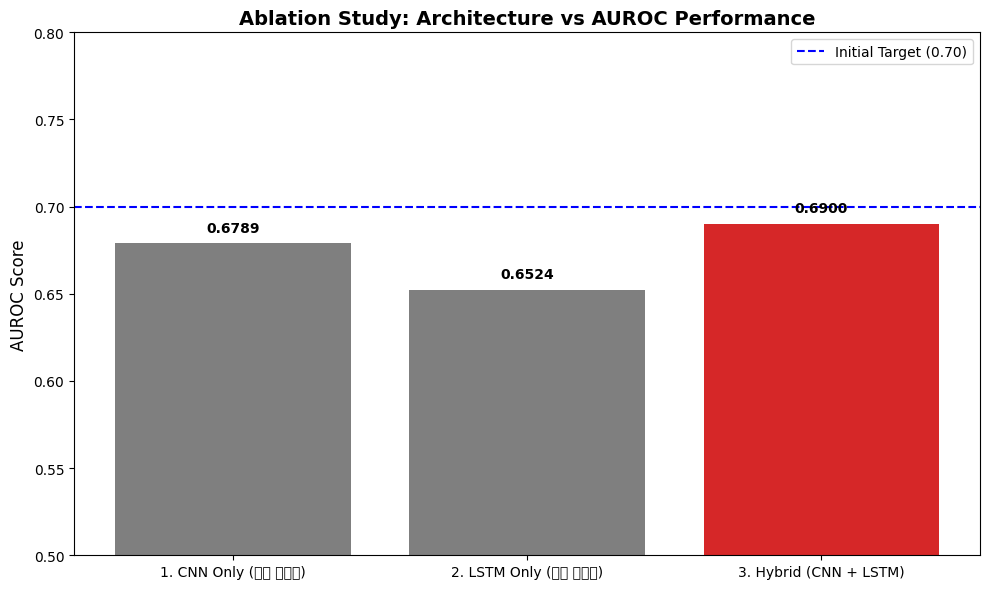

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import time

print("==================================================")
print(" 🔬 [Ablation Study] 모델 아키텍처별 성능 비교 실험 시작")
print("==================================================\n")

# ---------------------------------------------------------
# 1. Model A: 1D-CNN 단독 모델
# ---------------------------------------------------------
class CNNOnlyPredictor(nn.Module):
    def __init__(self, embedding_layer, embed_dim, max_len=15):
        super(CNNOnlyPredictor, self).__init__()
        self.embedding = embedding_layer
        # LSTM이 없으므로 채널 수를 64로 늘려 모델 용량(Capacity)을 보정
        self.conv = nn.Conv1d(embed_dim, 64, kernel_size=3, padding=1)
        self.dropout_cnn = nn.Dropout(0.2)

        # Flatten 후의 차원: 채널(64) * 시퀀스길이(15) = 960
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * max_len, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.embedding(x).permute(0, 2, 1)
        x = self.dropout_cnn(F.relu(self.conv(x)))
        return self.fc(x)

# ---------------------------------------------------------
# 2. Model B: Bi-LSTM 단독 모델
# ---------------------------------------------------------
class LSTMOnlyPredictor(nn.Module):
    def __init__(self, embedding_layer, embed_dim):
        super(LSTMOnlyPredictor, self).__init__()
        self.embedding = embedding_layer
        # CNN이 없으므로 원본 임베딩을 바로 LSTM에 입력
        self.lstm = nn.LSTM(embed_dim, 64, num_layers=2, batch_first=True, bidirectional=True, dropout=0.3)

        self.fc = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.embedding(x)
        _, (h_n, _) = self.lstm(x)
        # 양방향의 마지막 은닉 상태(Hidden state) 결합
        return self.fc(torch.cat((h_n[-2,:,:], h_n[-1,:,:]), dim=1))

# ---------------------------------------------------------
# 3. 간이 학습 및 평가 함수 (Ablation 전용)
# ---------------------------------------------------------
def train_and_evaluate_ablation(model, model_name, dataset, device, epochs=30):
    print(f"⏳ [{model_name}] 모델 학습 및 평가 중...")
    train_size = int(0.8 * len(dataset))

    train_loader = torch.utils.data.DataLoader(
        torch.utils.data.Subset(dataset, range(train_size)), batch_size=128, shuffle=True
    )
    val_loader = torch.utils.data.DataLoader(
        torch.utils.data.Subset(dataset, range(train_size, len(dataset))), batch_size=128
    )

    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
    criterion = nn.BCELoss()

    # 학습 루프 (Ablation은 경향성 파악이 목적이므로 빠른 비교를 위해 지정된 Epoch만 수행)
    for epoch in range(epochs):
        model.train()
        for seqs, labels in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(seqs.to(device)), labels.to(device))
            loss.backward()
            optimizer.step()

    # 평가 루프
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for seqs, labels in val_loader:
            preds = model(seqs.to(device)).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    all_preds = np.array(all_preds).flatten()
    all_labels = np.array(all_labels).flatten()

    auroc = roc_auc_score(all_labels, all_preds)
    print(f"   ✅ {model_name} AUROC: {auroc:.4f}\n")
    return auroc

# ---------------------------------------------------------
# 4. Ablation Study 실행부
# ---------------------------------------------------------
# 주의: 이 코드는 이전 셀에서 dataset, device, embed_layer, embed_dim이 선언되어 있어야 합니다.
if __name__ == "__main__":
    # 임베딩 레이어 복제 (각 모델이 독립적으로 학습하도록)
    import copy

    models_to_test = {
        "1. CNN Only (국소 특징만)": CNNOnlyPredictor(copy.deepcopy(embed_layer), embed_dim),
        "2. LSTM Only (전체 문맥만)": LSTMOnlyPredictor(copy.deepcopy(embed_layer), embed_dim),
        "3. Hybrid (CNN + LSTM)": FBPredictor(copy.deepcopy(embed_layer), embed_dim) # 기존 하이브리드 모델
    }

    results_auroc = {}

    start_time = time.time()
    for name, model in models_to_test.items():
        # 비교를 위해 각각 30 Epoch씩만 빠르게 돌려 비교
        auroc = train_and_evaluate_ablation(model, name, dataset, device, epochs=30)
        results_auroc[name] = auroc

    print(f"⏱️ Ablation Study 총 소요 시간: {time.time() - start_time:.2f}초")

    # ---------------------------------------------------------
    # 5. 결과 시각화 (기말 발표 PPT용)
    # ---------------------------------------------------------
    names = list(results_auroc.keys())
    scores = list(results_auroc.values())

    plt.figure(figsize=(10, 6))
    bars = plt.bar(names, scores, color=['#7f7f7f', '#7f7f7f', '#d62728']) # 하이브리드만 빨간색 강조

    plt.ylim(0.5, 0.8) # AUROC는 보통 0.5가 기본 찍기 확률이므로 0.5부터 시작
    plt.ylabel('AUROC Score', fontsize=12)
    plt.title('Ablation Study: Architecture vs AUROC Performance', fontsize=14, fontweight='bold')

    # 막대 위에 점수 텍스트 표시
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f"{yval:.4f}", ha='center', va='bottom', fontweight='bold')

    # 임상 허들/목표치 가이드라인 추가 (선택사항)
    plt.axhline(y=0.70, color='blue', linestyle='--', label='Initial Target (0.70)')
    plt.legend()

    plt.tight_layout()
    plt.show()